In [1]:
import pandas as pd

sales = pd.read_csv('../data/raw/walmart_train.csv')
features = pd.read_csv('../data/raw/walmart_features.csv')
stores = pd.read_csv('../data/raw/walmart_stores.csv')

print(sales.shape, features.shape, stores.shape)
sales.head()

(421570, 5) (8190, 12) (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [2]:
df = sales.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], how='left')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [3]:
# Summary of missing
print(df.isnull().sum().sort_values(ascending=False))

# Interpolate missing values for numeric features
for col in ['Temperature', 'CPI', 'Unemployment', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    if col in df.columns:
        df[col] = df[col].interpolate()

# Fill remaining with forward fill
df.fillna(method='ffill', inplace=True)

MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Store                0
Unemployment         0
CPI                  0
Fuel_Price           0
Dept                 0
Temperature          0
Size                 0
Type                 0
IsHoliday_x          0
Weekly_Sales         0
Date                 0
IsHoliday_y          0
dtype: int64


/var/folders/14/lwdqxjmj54dcx0n3tktty0gw0000gn/T/ipykernel_28377/1917722820.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
# ---------------------------
# 4. Feature Engineering Step
# ---------------------------

# Step 1: Choose one IsHoliday column and unify
if 'IsHoliday_x' in df.columns:
    df['IsHoliday'] = df['IsHoliday_x']
elif 'IsHoliday_y' in df.columns:
    df['IsHoliday'] = df['IsHoliday_y']
else:
    raise ValueError("IsHoliday column not found")

# Drop old holiday columns to clean up
df.drop(columns=['IsHoliday_x', 'IsHoliday_y'], errors='ignore', inplace=True)

# Convert to binary integer
df['IsHoliday'] = df['IsHoliday'].astype(int)

# Step 2: Create time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

# Step 3: Interpolate MarkDown1-5 columns (fill missing with forward fill)
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    if col in df.columns:
        df[col] = df[col].interpolate().fillna(0)

# Step 4: Categoricals as string type
df['Dept'] = df['Dept'].astype(str)
df['Store'] = df['Store'].astype(str)
df['Type'] = df['Type'].astype(str)

# Step 5: Confirm success
print("✅ Feature engineering completed.")
df.head()

✅ Feature engineering completed.


,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,CPI,Unemployment,Year,Month,Week,Day,IsHoliday,Quarter,IsMonthStart,IsMonthEnd
0,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,0.0,0.0,...,211.096358,8.106,2010,2,5,4,0,1,0,0
1,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,0.0,0.0,...,211.242170,8.106,2010,2,6,4,1,1,0,0
2,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,0.0,0.0,...,211.289143,8.106,2010,2,7,4,0,1,0,0
3,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,0.0,0.0,...,211.319643,8.106,2010,2,8,4,0,1,0,0
4,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,0.0,0.0,...,211.350143,8.106,2010,3,9,4,0,1,0,0


In [6]:
df.to_csv('../data/processed/cleaned_walmart_data.csv', index=False)

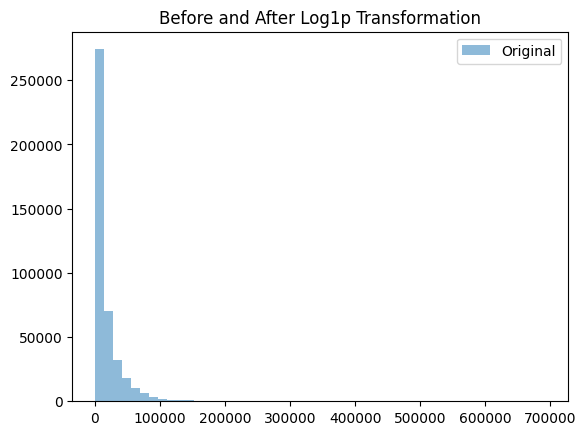

In [12]:
import numpy as np

# Feature engineering
df = df[df['Weekly_Sales'] > 0]  # Option 1: drop zero or negative sales
df['Weekly_Sales_Log'] = np.log1p(df['Weekly_Sales'])

# Optional: histogram check (optional)
import matplotlib.pyplot as plt
plt.hist(df['Weekly_Sales'], bins=50, alpha=0.5, label='Original')
#plt.hist(df['Weekly_Sales_Log'], bins=50, alpha=0.5, label='Log Transformed')
plt.legend()
plt.title("Before and After Log1p Transformation")
plt.show()

In [10]:
df.to_csv('../data/processed/cleaned_walmart_data.csv', index=False)

In [13]:
print(df.columns)
print(df[['Weekly_Sales']].head())

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Type', 'Size', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Day',
       'IsHoliday', 'Quarter', 'IsMonthStart', 'IsMonthEnd',
       'Weekly_Sales_Log'],
      dtype='object')
   Weekly_Sales
0      24924.50
1      46039.49
2      41595.55
3      19403.54
4      21827.90
